# MLP SHAP Inspection

This notebook inspects the saved MLP default-risk model with SHAP. It rebuilds the same engineered-feature preprocessing used during training, loads `credit_default_mlp.pt`, and explains the model output on a manageable test sample.

The SHAP values here explain the model logit output. Positive values push a client toward higher predicted default risk, while negative values push toward lower predicted default risk.

## Required Packages

Install these in the `fairfed` environment if needed:

```bash
conda activate fairfed
conda install scikit-learn matplotlib pandas
pip install torch shap xlrd
```

`xlrd` is needed because the source dataset is an `.xls` file.

In [1]:
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import torch
from torch.utils.data import DataLoader, TensorDataset

import shap

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

repo_root = Path.cwd()
while not (repo_root / "data").exists() and repo_root != repo_root.parent:
    repo_root = repo_root.parent

import sys
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

try:
    from src.dataset.credit_data import add_features
    from src.training.credit_mlp import CreditDefaultMLP, build_mlp_from_artifact, normalize_mlp_config
except ModuleNotFoundError:
    import sys

    sys.path.append(str(Path.cwd()))
    from src.dataset.credit_data import add_features
    from src.training.credit_mlp import CreditDefaultMLP, build_mlp_from_artifact, normalize_mlp_config

DEFAULT_CATEGORICAL_COLS = ["SEX", "EDUCATION", "MARRIAGE", "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
PAY_STATUS_COLS = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
DELAY_SUMMARY_COLS = ["MAX_PAY_DELAY", "AVG_PAY_DELAY", "MONTHS_WITH_DELAY"]
FOCUSED_PERMUTATION_FEATURES = ["SEX", *PAY_STATUS_COLS, *DELAY_SUMMARY_COLS]


def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def load_credit_default_data():
    data_path = repo_root / "data" / "default_of_credit_card_clients.xls"
    return pd.read_excel(data_path, header=1), data_path, "default payment next month"


def load_torch_artifact(device=None):
    model_path = repo_root / "models" / "credit_default_mlp.pt"
    try:
        artifact = torch.load(model_path, map_location=device, weights_only=False)
    except TypeError:
        artifact = torch.load(model_path, map_location=device)
    return artifact, model_path


def prepare_feature_set(source_df, target_col, use_feature_engineering, seed, categorical_cols=DEFAULT_CATEGORICAL_COLS, y_dtype=None, output_dtype=None):
    model_df = add_features(source_df) if use_feature_engineering else source_df.copy()
    X_raw = model_df.drop(columns=["ID", target_col])
    y_raw = model_df[target_col].astype(y_dtype) if y_dtype is not None else model_df[target_col]
    numeric_cols = [col for col in X_raw.columns if col not in categorical_cols]

    X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
        X_raw, y_raw, test_size=0.30, random_state=seed, stratify=y_raw
    )
    X_val_raw, X_test_raw, y_val, y_test = train_test_split(
        X_temp_raw, y_temp, test_size=0.50, random_state=seed, stratify=y_temp
    )

    preprocess = ColumnTransformer(
        transformers=[
            ("numeric", StandardScaler(), numeric_cols),
            ("categorical", make_one_hot_encoder(), categorical_cols),
        ]
    )

    X_train = preprocess.fit_transform(X_train_raw)
    X_val = preprocess.transform(X_val_raw)
    X_test = preprocess.transform(X_test_raw)

    if output_dtype is not None:
        X_train = X_train.astype(output_dtype)
        X_val = X_val.astype(output_dtype)
        X_test = X_test.astype(output_dtype)

    return {
        "preprocess": preprocess,
        "categorical_cols": list(categorical_cols),
        "numeric_cols": numeric_cols,
        "X_train_raw": X_train_raw,
        "X_val_raw": X_val_raw,
        "X_test_raw": X_test_raw,
        "X_train": X_train,
        "X_val": X_val,
        "X_test": X_test,
        "y_train": y_train,
        "y_val": y_val,
        "y_test": y_test,
    }


def make_credit_default_mlp(input_dim, model_config=None, device=None):
    model_config = normalize_mlp_config(model_config)
    model = CreditDefaultMLP(
        input_dim,
        hidden_dims=model_config["hidden_dims"],
        dropout=model_config["dropout"],
        use_batch_norm=model_config["batch_norm"],
    )
    return model.to(device) if device is not None else model


def make_torch_dataset(X_array, y_series=None):
    X_tensor = torch.tensor(X_array, dtype=torch.float32)
    if y_series is None:
        return TensorDataset(X_tensor)
    y_values = y_series.to_numpy() if hasattr(y_series, "to_numpy") else y_series
    y_tensor = torch.tensor(y_values, dtype=torch.float32).view(-1, 1)
    return TensorDataset(X_tensor, y_tensor)


def predict_mlp_proba(model, X_array, y_series=None, device=None, batch_size=1024):
    loader = DataLoader(make_torch_dataset(X_array, y_series), batch_size=batch_size, shuffle=False)
    model.eval()
    probs = []
    targets = []
    with torch.no_grad():
        for batch in loader:
            if y_series is None:
                (xb,) = batch
            else:
                xb, yb = batch
                targets.append(yb.numpy().ravel())
            logits = model(xb.to(device) if device is not None else xb)
            probs.append(torch.sigmoid(logits).cpu().numpy().ravel())
    y_prob = np.concatenate(probs)
    if y_series is None:
        return y_prob
    return np.concatenate(targets), y_prob


def make_mlp_predict_proba(model, device=None, batch_size=1024):
    def predict_proba(X_array):
        return predict_mlp_proba(model, X_array, device=device, batch_size=batch_size)
    return predict_proba


def transformed_feature_names(column_transformer):
    names = []
    for transformer_name, transformer, columns in column_transformer.transformers_:
        if transformer_name == "remainder" and transformer == "drop":
            continue
        if transformer_name == "categorical":
            names.extend(transformer.get_feature_names_out(columns).tolist())
        else:
            names.extend(list(columns))
    return names


def original_feature_name(transformed_name, categorical_cols=DEFAULT_CATEGORICAL_COLS):
    for col in categorical_cols:
        if transformed_name.startswith(f"{col}_"):
            return col
    return transformed_name


def feature_groups_from_names(feature_names, categorical_cols=DEFAULT_CATEGORICAL_COLS):
    groups = {}
    for idx, feature_name in enumerate(feature_names):
        groups.setdefault(original_feature_name(feature_name, categorical_cols), []).append(idx)
    return groups


def score_binary_predictions(y_true, y_prob):
    return {
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
    }


def sample_rows(X, y, sample_size, random_state):
    sample_size = min(sample_size, X.shape[0])
    rng = np.random.default_rng(random_state)
    sample_idx = rng.choice(X.shape[0], size=sample_size, replace=False)
    y_sample = y.iloc[sample_idx].to_numpy() if hasattr(y, "iloc") else y[sample_idx]
    return X[sample_idx], y_sample, sample_idx


def single_column_groups(feature_names):
    return [[idx] for idx in range(len(feature_names))], list(feature_names)


def grouped_feature_columns(feature_groups):
    group_names = list(feature_groups.keys())
    group_cols = [feature_groups[name] for name in group_names]
    return group_cols, group_names


def delay_permutation_groups(feature_groups):
    repayment_status_cols = sorted(
        col_idx for feature in PAY_STATUS_COLS for col_idx in feature_groups[feature]
    )
    custom_groups = [repayment_status_cols]
    custom_group_names = ["ALL_PAY_STATUS"]

    if all(feature in feature_groups for feature in DELAY_SUMMARY_COLS):
        engineered_delay_cols = sorted(
            col_idx for feature in DELAY_SUMMARY_COLS for col_idx in feature_groups[feature]
        )
        custom_groups.append(engineered_delay_cols)
        custom_group_names.append("ENGINEERED_DELAY_SUMMARIES")
        custom_groups.append(sorted(set(repayment_status_cols + engineered_delay_cols)))
        custom_group_names.append("ALL_DELAY_FEATURES")

    return custom_groups, custom_group_names


def calculate_permutation_importance(X, y, predict_proba, groups, group_names, metric_name="roc_auc", n_repeats=5, random_state=42):
    rng = np.random.default_rng(random_state)
    baseline_prob = predict_proba(X)
    baseline_metric = score_binary_predictions(y, baseline_prob)[metric_name]
    rows = []

    for group_name, group_cols in zip(group_names, groups):
        permuted_metrics = []
        for _ in range(n_repeats):
            X_permuted = X.copy()
            shuffled_rows = rng.permutation(X.shape[0])
            X_permuted[:, group_cols] = X_permuted[shuffled_rows][:, group_cols]
            permuted_prob = predict_proba(X_permuted)
            permuted_metrics.append(score_binary_predictions(y, permuted_prob)[metric_name])

        permuted_metrics = np.asarray(permuted_metrics)
        drops = baseline_metric - permuted_metrics
        rows.append({
            "feature": group_name,
            "n_transformed_columns": len(group_cols),
            "baseline_score": baseline_metric,
            "permuted_score_mean": permuted_metrics.mean(),
            "importance_mean": drops.mean(),
            "importance_std": drops.std(ddof=1) if n_repeats > 1 else 0.0,
        })

    return pd.DataFrame(rows).sort_values("importance_mean", ascending=False).reset_index(drop=True)


Device: cuda


/homes/sguszausky/miniconda3/envs/fairfed/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df, DATA_PATH, target_col = load_credit_default_data()
artifact, MODEL_PATH = load_torch_artifact(device=device)

print("Data:", DATA_PATH, df.shape)
print("Model:", MODEL_PATH)
print("Saved feature set:", artifact.get("feature_set"))
print("Saved threshold:", round(float(artifact.get("best_threshold", 0.5)), 3))


Data: ../data/default_of_credit_card_clients.xls (30000, 25)
Model: ../models/credit_default_mlp.pt
Saved feature set: engineered
Saved threshold: 0.58


## Rebuild the Training Preprocessing

The saved model file stores the weights and feature-set metadata, but not the fitted `ColumnTransformer`. To reproduce the model inputs, this cell recreates the same feature engineering, split, scaling, and one-hot encoding used in `train_global_mlp.ipynb`.


In [3]:
categorical_cols = artifact.get("categorical_cols", DEFAULT_CATEGORICAL_COLS)

active_data = prepare_feature_set(
    df,
    target_col=target_col,
    use_feature_engineering=artifact.get("use_feature_engineering", True),
    seed=SEED,
    categorical_cols=categorical_cols,
    y_dtype=np.float32,
    output_dtype=np.float32,
)
X_train = active_data["X_train"]
X_val = active_data["X_val"]
X_test = active_data["X_test"]
y_val = active_data["y_val"]
y_test = active_data["y_test"]
preprocess = active_data["preprocess"]

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
print("Input dim matches artifact:", X_train.shape[1] == artifact["input_dim"])


Train: (21000, 105) Val: (4500, 105) Test: (4500, 105)
Input dim matches artifact: True


In [4]:
model, _ = build_mlp_from_artifact(artifact)
model = model.to(device)
model.eval()

print(model)


CreditDefaultMLP(
  (net): Sequential(
    (0): Linear(in_features=105, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.25, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.15, inplace=False)
    (12): Linear(in_features=64, out_features=32, bias=True)
    (13): ReLU()
    (14): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [5]:
y_val_true, y_val_prob = predict_mlp_proba(model, X_val, y_val, device=device)
y_test_true, y_test_prob = predict_mlp_proba(model, X_test, y_test, device=device)

print("Validation ROC-AUC:", round(roc_auc_score(y_val_true, y_val_prob), 4))
print("Validation PR-AUC:", round(average_precision_score(y_val_true, y_val_prob), 4))
print("Test ROC-AUC:", round(roc_auc_score(y_test_true, y_test_prob), 4))
print("Test PR-AUC:", round(average_precision_score(y_test_true, y_test_prob), 4))


Validation ROC-AUC: 0.7783
Validation PR-AUC: 0.5428
Test ROC-AUC: 0.7785
Test PR-AUC: 0.5572


## Build SHAP Samples

Deep SHAP can be slow if every row is explained. The background sample represents the training distribution, and the explanation sample is a reproducible subset of test rows.

In [6]:
feature_names = transformed_feature_names(preprocess)
print("Feature names:", len(feature_names))
feature_names[:10]


Feature names: 105


['LIMIT_BAL',
 'AGE',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2']

In [7]:
BACKGROUND_SIZE = min(256, X_train.shape[0])
EXPLAIN_SIZE = min(500, X_test.shape[0])

rng = np.random.default_rng(SEED)
background_idx = rng.choice(X_train.shape[0], size=BACKGROUND_SIZE, replace=False)
explain_idx = rng.choice(X_test.shape[0], size=EXPLAIN_SIZE, replace=False)

X_background = torch.tensor(X_train[background_idx], dtype=torch.float32, device=device)
X_explain = torch.tensor(X_test[explain_idx], dtype=torch.float32, device=device)
X_explain_np = X_test[explain_idx]
X_explain_raw = active_data["X_test_raw"].iloc[explain_idx].copy()
y_explain = y_test.iloc[explain_idx].to_numpy()
prob_explain = y_test_prob[explain_idx]

print("Background:", X_background.shape)
print("Explained test rows:", X_explain.shape)

Background: torch.Size([256, 105])
Explained test rows: torch.Size([500, 105])


## Global SHAP Summary

The summary plot ranks transformed model inputs by their average absolute SHAP value. Numeric features appear as scaled values, and categorical features appear as one-hot indicators.

In [8]:
explainer = shap.DeepExplainer(model, X_background)
raw_shap_values = explainer.shap_values(X_explain)

if isinstance(raw_shap_values, list):
    shap_values = raw_shap_values[0]
else:
    shap_values = raw_shap_values

shap_values = np.asarray(shap_values)
if shap_values.ndim == 3 and shap_values.shape[-1] == 1:
    shap_values = shap_values.squeeze(-1)

expected_value = explainer.expected_value
if isinstance(expected_value, (list, tuple, np.ndarray)):
    expected_value = np.asarray(expected_value).reshape(-1)[0]

print("SHAP values:", shap_values.shape)
print("Expected logit:", round(float(expected_value), 4))

SHAP values: (500, 105)
Expected logit: -0.4866


/homes/sguszausky/.tmp/ipykernel_769520/1530004389.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


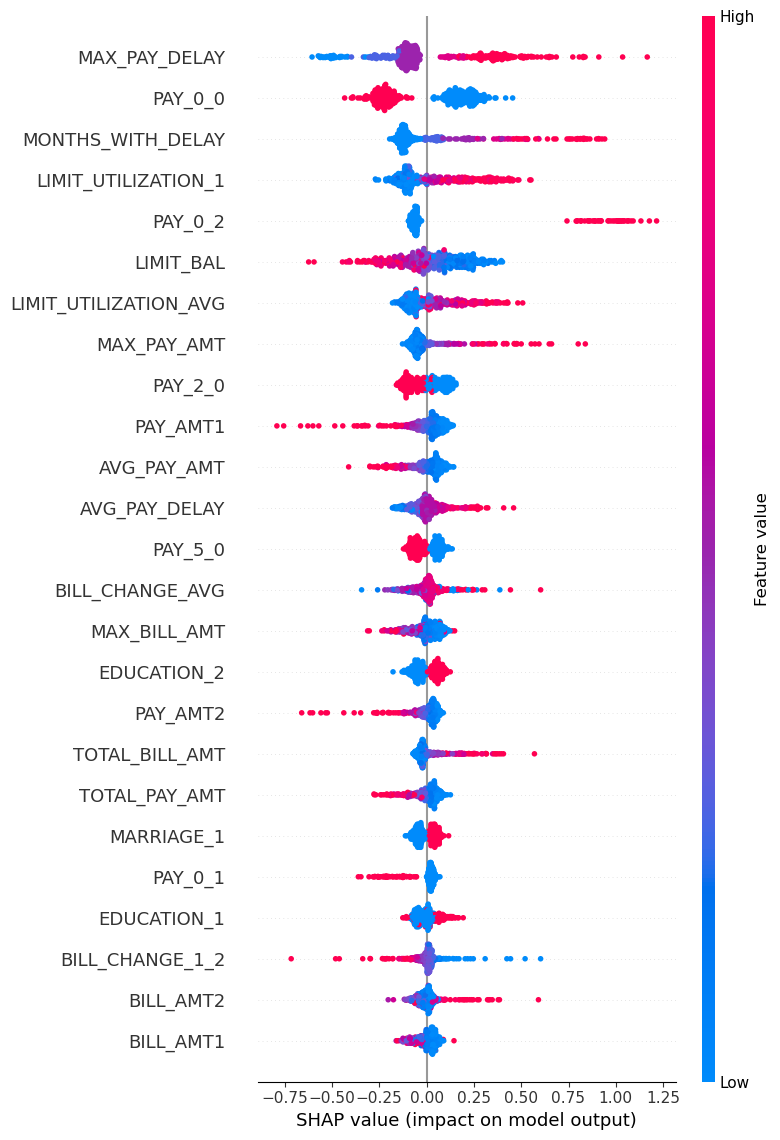

In [9]:
shap.summary_plot(
    shap_values,
    X_explain_np,
    feature_names=feature_names,
    max_display=25,
    show=True,
)

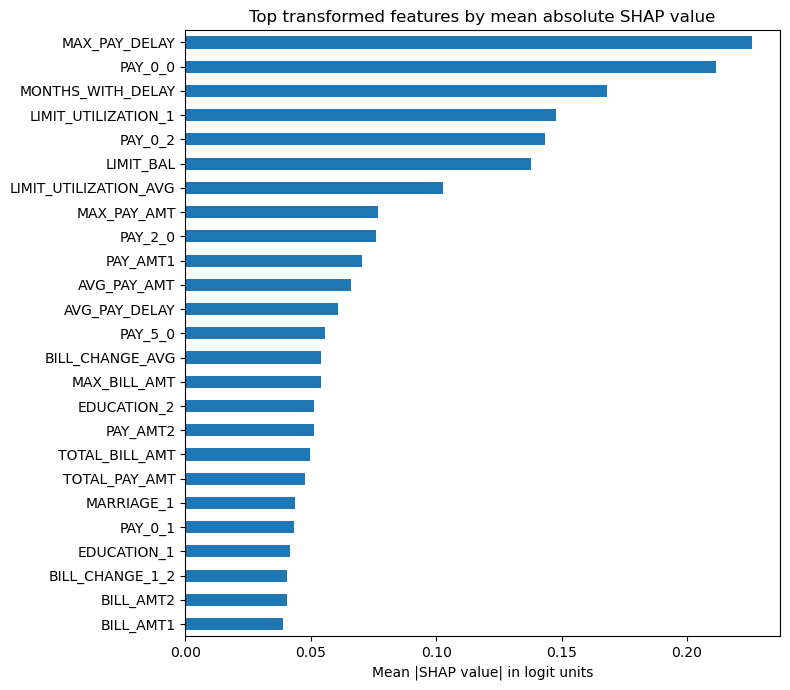

,mean_abs_shap
MAX_PAY_DELAY,0.225780
PAY_0_0,0.211724
MONTHS_WITH_DELAY,0.168178
LIMIT_UTILIZATION_1,0.147779
PAY_0_2,0.143247
LIMIT_BAL,0.137762
LIMIT_UTILIZATION_AVG,0.102639
MAX_PAY_AMT,0.076918
PAY_2_0,0.075948
PAY_AMT1,0.070567


In [10]:
mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=feature_names).sort_values(ascending=False)
mean_abs_shap.head(25).plot(kind="barh", figsize=(8, 7))
plt.gca().invert_yaxis()
plt.title("Top transformed features by mean absolute SHAP value")
plt.xlabel("Mean |SHAP value| in logit units")
plt.tight_layout()
plt.show()

mean_abs_shap.head(25).to_frame("mean_abs_shap")

## Aggregate One-Hot Features

The MLP sees one-hot encoded categories, but for inspection it is often easier to group those one-hot columns back under their original feature names.

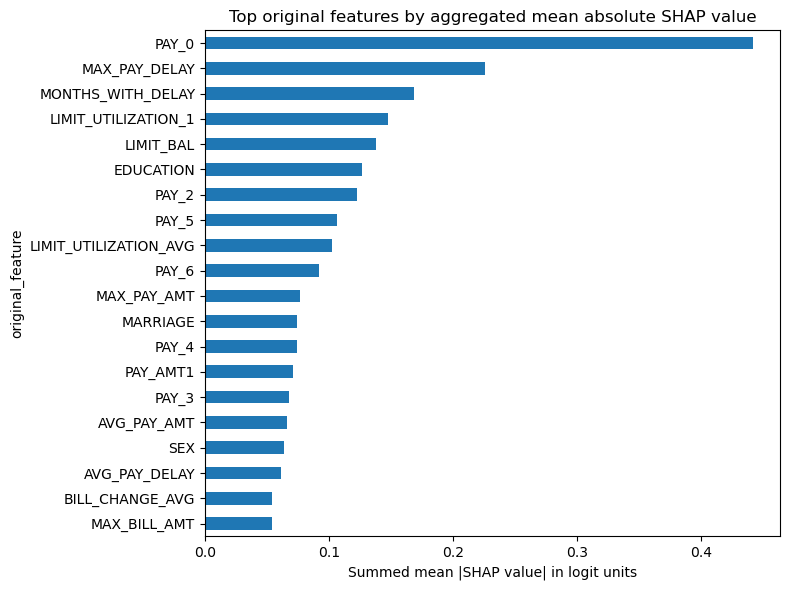

,aggregated_mean_abs_shap
original_feature,
PAY_0,0.441409
MAX_PAY_DELAY,0.225780
MONTHS_WITH_DELAY,0.168178
LIMIT_UTILIZATION_1,0.147779
LIMIT_BAL,0.137762
EDUCATION,0.126361
PAY_2,0.122108
PAY_5,0.106130
LIMIT_UTILIZATION_AVG,0.102639


In [11]:
grouped_importance = (
    mean_abs_shap.rename_axis("transformed_feature")
    .reset_index(name="mean_abs_shap")
    .assign(
        original_feature=lambda data: data["transformed_feature"].map(
            lambda name: original_feature_name(name, categorical_cols)
        )
    )
    .groupby("original_feature", as_index=True)["mean_abs_shap"]
    .sum()
    .sort_values(ascending=False)
)

grouped_importance.head(20).plot(kind="barh", figsize=(8, 6))
plt.gca().invert_yaxis()
plt.title("Top original features by aggregated mean absolute SHAP value")
plt.xlabel("Summed mean |SHAP value| in logit units")
plt.tight_layout()
plt.show()

grouped_importance.head(20).to_frame("aggregated_mean_abs_shap")


## Local Explanation

This section explains one test case. By default it chooses the highest predicted default-risk case from the explained sample.

In [12]:
local_pos = int(np.argmax(prob_explain))

print("Explained sample position:", local_pos)
print("Observed default:", int(y_explain[local_pos]))
print("Predicted default probability:", round(float(prob_explain[local_pos]), 4))

display(X_explain_raw.iloc[[local_pos]])

Explained sample position: 274
Observed default: 1
Predicted default probability: 0.9382


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,AVG_BILL_AMT,MAX_BILL_AMT,TOTAL_PAY_AMT,AVG_PAY_AMT,MAX_PAY_AMT,PAY_TO_BILL_RATIO,LIMIT_UTILIZATION_1,LIMIT_UTILIZATION_AVG,BILL_CHANGE_1_2,BILL_CHANGE_AVG
9286,100000,2,1,1,42,2,2,2,2,2,...,48169.166667,50823,11700,1950.0,3900,0.040482,0.461945,0.481687,-971,925.6


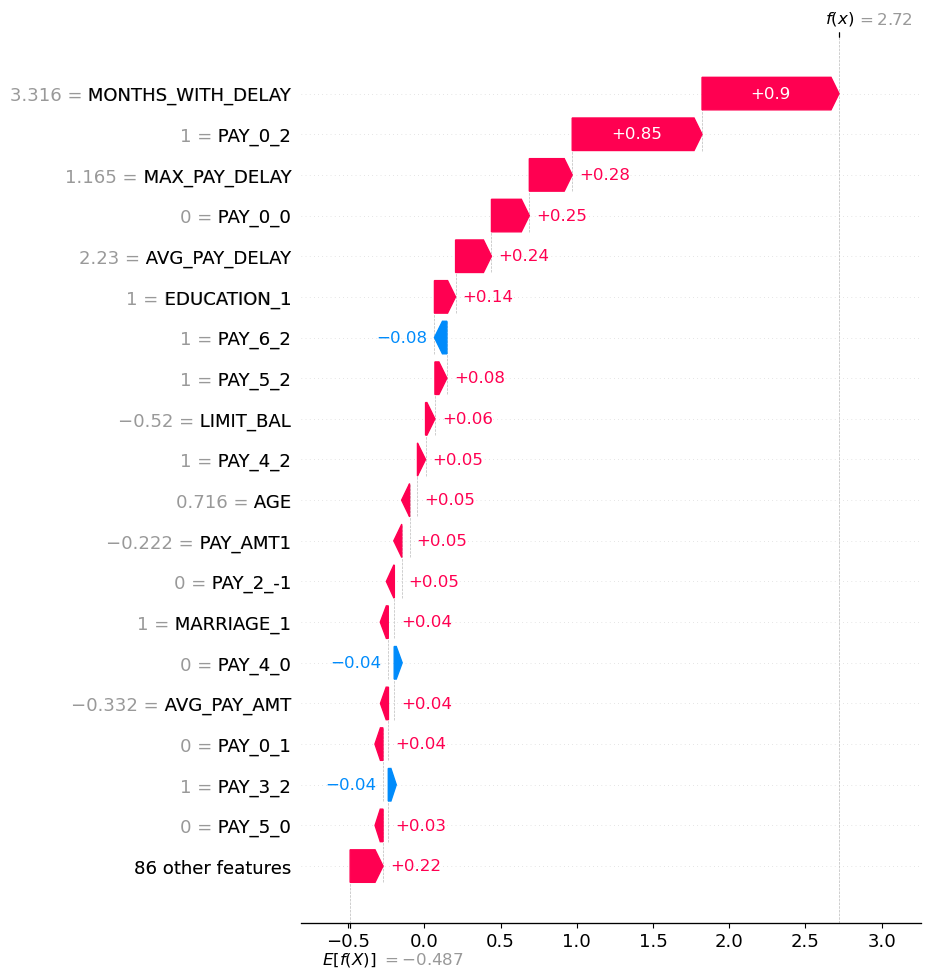

In [13]:
local_explanation = shap.Explanation(
    values=shap_values[local_pos],
    base_values=float(expected_value),
    data=X_explain_np[local_pos],
    feature_names=feature_names,
)

shap.plots.waterfall(local_explanation, max_display=20)